In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Define two 2D vectors
v1 = np.array([2, 3])
v2 = np.array([4, 1])

print("Vector v1:", v1)
print("Vector v2:", v2)


Vector v1: [2 3]
Vector v2: [4 1]


In [3]:
# Manual addition
v_add = np.array([v1[0] + v2[0], v1[1] + v2[1]])
print("v1 + v2 =", v_add)


v1 + v2 = [6 4]


In [4]:
# Scalar multiplication
c = 3
v_scaled = np.array([c * v1[0], c * v1[1]])
print(f"{c} * v1 =", v_scaled)


3 * v1 = [6 9]


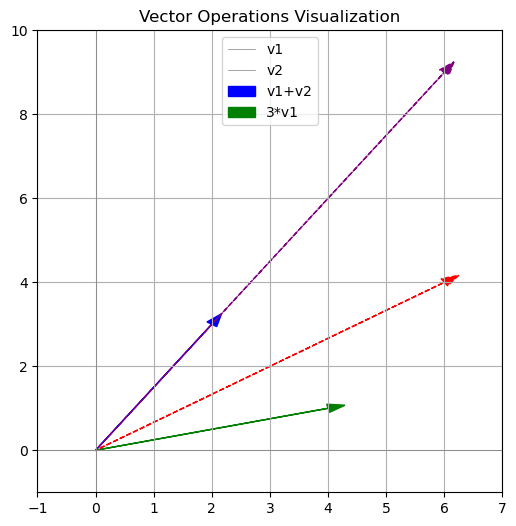

In [5]:
# Set up plot
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray', linewidth=0.5)  # X-axis
plt.axvline(0, color='gray', linewidth=0.5)  # Y-axis

# Plot original vectors
plt.arrow(0, 0, v1[0], v1[1], head_width=0.2, head_length=0.3, color='blue', label='v1')
plt.arrow(0, 0, v2[0], v2[1], head_width=0.2, head_length=0.3, color='green', label='v2')

# Plot vector addition result
plt.arrow(0, 0, v_add[0], v_add[1], head_width=0.2, head_length=0.3, color='red', linestyle='--', label='v1+v2')

# Plot scalar multiplication
plt.arrow(0, 0, v_scaled[0], v_scaled[1], head_width=0.2, head_length=0.3, color='purple', linestyle='--', label=f'{c}*v1')

# Labels and grid
plt.xlim(-1, max(v_scaled[0], v_add[0], v1[0], v2[0]) + 1)
plt.ylim(-1, max(v_scaled[1], v_add[1], v1[1], v2[1]) + 1)
plt.grid(True)
plt.legend(['v1', 'v2', 'v1+v2', f'{c}*v1'])
plt.title("Vector Operations Visualization")
plt.show()


In [6]:
# Existing points (as vectors)
points = np.array([
    [1, 2],  # P1, Class A
    [2, 3],  # P2, Class A
    [6, 5],  # P3, Class B
    [7, 7]   # P4, Class B
])

# Classes (for coloring)
classes = ['A', 'A', 'B', 'B']

# New point to classify
P_new = np.array([3, 4])


In [7]:
# Euclidean distances
distances = np.sqrt(np.sum((points - P_new)**2, axis=1))
for i, d in enumerate(distances):
    print(f"Distance from P_new to P{i+1}:", round(d, 3))


Distance from P_new to P1: 2.828
Distance from P_new to P2: 1.414
Distance from P_new to P3: 3.162
Distance from P_new to P4: 5.0


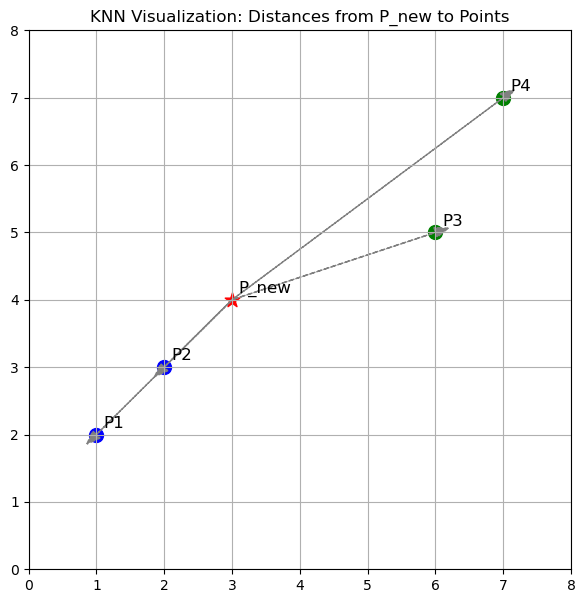

In [8]:
plt.figure(figsize=(7,7))
colors = {'A':'blue', 'B':'green'}

# Plot original points
for i, point in enumerate(points):
    plt.scatter(point[0], point[1], color=colors[classes[i]], s=100)
    plt.text(point[0]+0.1, point[1]+0.1, f'P{i+1}', fontsize=12)

# Plot new point
plt.scatter(P_new[0], P_new[1], color='red', s=120, marker='*')
plt.text(P_new[0]+0.1, P_new[1]+0.1, 'P_new', fontsize=12)

# Draw arrows (vectors) from P_new to all points
for i, point in enumerate(points):
    vector = point - P_new
    plt.arrow(P_new[0], P_new[1], vector[0], vector[1], head_width=0.15, head_length=0.2, color='gray', linestyle='--')

plt.xlim(0, 8)
plt.ylim(0, 8)
plt.grid(True)
plt.title("KNN Visualization: Distances from P_new to Points")
plt.show()


In [9]:
# Points (2D)
points = np.array([
    [1, 2],  # P1
    [2, 3],  # P2
    [6, 5],  # P3
    [7, 7]   # P4
])

# Classes
classes = ['A', 'A', 'B', 'B']

# New point to classify
P_new = np.array([3, 4])

# Number of neighbors
k = 3


In [10]:
# Euclidean distances
distances = np.sqrt(np.sum((points - P_new)**2, axis=1))

# Combine distances and classes
dist_class = list(zip(distances, classes))

# Sort by distance
dist_class_sorted = sorted(dist_class, key=lambda x: x[0])

# Pick k nearest neighbors
k_neighbors = dist_class_sorted[:k]

print("k nearest neighbors (distance, class):")
for d, c in k_neighbors:
    print(round(d, 3), c)


k nearest neighbors (distance, class):
1.414 A
2.828 A
3.162 B


In [11]:
# Count votes
from collections import Counter
neighbor_classes = [c for _, c in k_neighbors]
vote_count = Counter(neighbor_classes)

# Class with most votes
predicted_class = vote_count.most_common(1)[0][0]
print("Predicted class for P_new:", predicted_class)


Predicted class for P_new: A


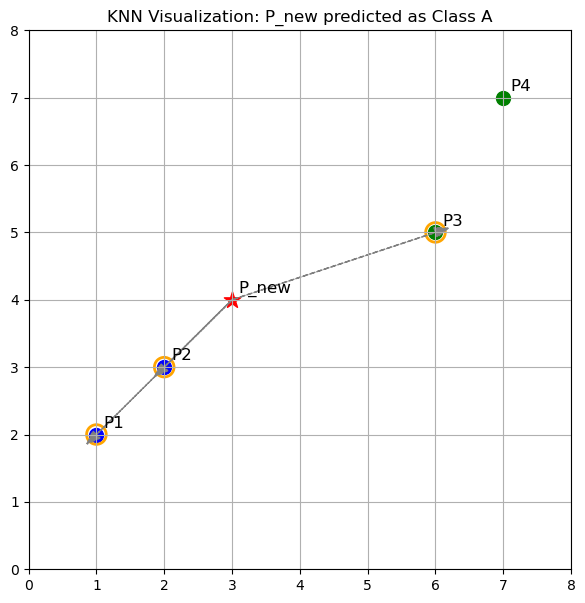

In [12]:
plt.figure(figsize=(7,7))
colors = {'A':'blue', 'B':'green'}

# Plot all points
for i, point in enumerate(points):
    plt.scatter(point[0], point[1], color=colors[classes[i]], s=100)
    plt.text(point[0]+0.1, point[1]+0.1, f'P{i+1}', fontsize=12)

# Plot new point
plt.scatter(P_new[0], P_new[1], color='red', s=150, marker='*')
plt.text(P_new[0]+0.1, P_new[1]+0.1, 'P_new', fontsize=12)

# Highlight k nearest neighbors
for d, c in k_neighbors:
    idx = np.where(distances == d)[0][0]
    neighbor = points[idx]
    plt.scatter(neighbor[0], neighbor[1], s=200, facecolors='none', edgecolors='orange', linewidths=2)

# Draw arrows from P_new to k nearest neighbors
for d, c in k_neighbors:
    idx = np.where(distances == d)[0][0]
    vector = points[idx] - P_new
    plt.arrow(P_new[0], P_new[1], vector[0], vector[1], head_width=0.15, head_length=0.2, color='gray', linestyle='--')

plt.xlim(0, 8)
plt.ylim(0, 8)
plt.grid(True)
plt.title(f"KNN Visualization: P_new predicted as Class {predicted_class}")
plt.show()


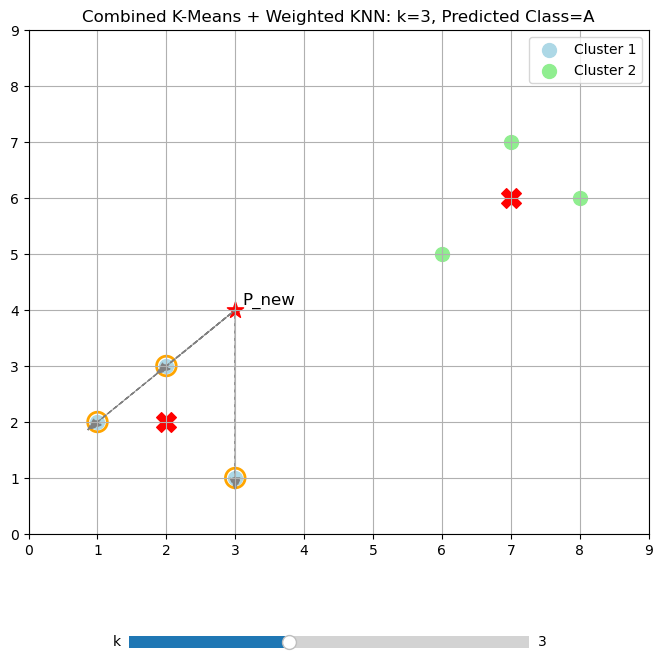

In [13]:
# ===============================
# 1️⃣ Imports
# ===============================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from collections import Counter
import time

# ===============================
# 2️⃣ Dataset
# ===============================
# Points for clustering
points_cluster = np.array([
    [1, 2],
    [2, 3],
    [3, 1],
    [6, 5],
    [7, 7],
    [8, 6]
])

# Labels for KNN (use same points for simplicity)
classes_knn = ['A', 'A', 'B', 'B', 'B', 'B']

# New point to classify
P_new = np.array([3, 4])

# Number of clusters for K-Means
k_clusters = 2

# Initial centroids for K-Means
centroids = np.array([points_cluster[0], points_cluster[3]])

# ===============================
# 3️⃣ Weighted KNN Function
# ===============================
def weighted_knn(points, classes, P_new, k):
    distances = np.sqrt(np.sum((points - P_new)**2, axis=1))
    dist_class = list(zip(distances, classes, range(len(points))))
    dist_class_sorted = sorted(dist_class, key=lambda x: x[0])
    k_neighbors = dist_class_sorted[:k]
    
    votes = {}
    for d, c, idx in k_neighbors:
        weight = 1/d if d != 0 else 1e5
        votes[c] = votes.get(c, 0) + weight
    
    predicted_class = max(votes, key=votes.get)
    return predicted_class, k_neighbors, distances

# ===============================
# 4️⃣ K-Means Assignment
# ===============================
def assign_clusters(points, centroids):
    clusters = {i: [] for i in range(len(centroids))}
    for p in points:
        distances = np.sqrt(np.sum((centroids - p)**2, axis=1))
        cluster_idx = np.argmin(distances)
        clusters[cluster_idx].append(p)
    return clusters

def update_centroids(clusters, centroids):
    for i in clusters:
        if clusters[i]:
            centroids[i] = np.mean(clusters[i], axis=0)
    return centroids

# ===============================
# 5️⃣ Combined Visualization Function
# ===============================
def plot_combined(k_knn):
    plt.cla()
    
    # ===== K-Means Clustering =====
    clusters = assign_clusters(points_cluster, centroids)
    current_centroids = update_centroids(clusters, centroids.copy())
    colors_cluster = ['lightblue', 'lightgreen']
    
    for i, cluster_points in clusters.items():
        cluster_points = np.array(cluster_points)
        plt.scatter(cluster_points[:,0], cluster_points[:,1], color=colors_cluster[i], s=100, label=f'Cluster {i+1}')
        plt.scatter(current_centroids[i][0], current_centroids[i][1], color='red', s=200, marker='X')  # centroid
    
    # ===== Weighted KNN =====
    predicted_class, k_neighbors, distances = weighted_knn(points_cluster, classes_knn, P_new, int(k_knn))
    color_map_knn = {'A':'blue', 'B':'green'}
    
    # New point
    plt.scatter(P_new[0], P_new[1], color='red', s=150, marker='*')
    plt.text(P_new[0]+0.1, P_new[1]+0.1, 'P_new', fontsize=12)
    
    # Highlight k nearest neighbors
    for d, c, idx in k_neighbors:
        neighbor = points_cluster[idx]
        plt.scatter(neighbor[0], neighbor[1], s=200, facecolors='none', edgecolors='orange', linewidths=2)
        plt.arrow(P_new[0], P_new[1], neighbor[0]-P_new[0], neighbor[1]-P_new[1],
                  head_width=0.15, head_length=0.2, color='gray', linestyle='--')
    
    plt.title(f"Combined K-Means + Weighted KNN: k={int(k_knn)}, Predicted Class={predicted_class}")
    plt.xlim(0, 9)
    plt.ylim(0, 9)
    plt.grid(True)
    plt.legend()
    plt.draw()

# ===============================
# 6️⃣ Interactive Slider
# ===============================
fig, ax = plt.subplots(figsize=(8,8))
plt.subplots_adjust(bottom=0.25)
plot_combined(3)

ax_k = plt.axes([0.25, 0.1, 0.5, 0.03])
slider_k = Slider(ax_k, 'k', 1, len(points_cluster), valinit=3, valstep=1)

def update(val):
    plot_combined(slider_k.val)

slider_k.on_changed(update)
plt.show()
